# Ensemble ResNet50 + LightGBM + DistilBERT — PetFinder Adoption Prediction
**Grupo 8 — Maestría en Ciencia de Datos — Laboratorio 2**

Este notebook combina las predicciones del pipeline tabular (LightGBM), del pipeline de imágenes (ResNet50) y del pipeline de texto (DistilBERT) mediante un ensemble ponderado con búsqueda de pesos en grilla 2D. **No requiere GPU ni entrenamiento** — solo combina predicciones ya calculadas.

---

### Archivos necesarios (3)

| Archivo | Origen |
|---|---|
| `best_lgb_predictions.joblib` | `PETFINDER_GRUPO8_R10/Tabular/work/` |
| `resnet_best_predictions.joblib` | `PETFINDER_GRUPO8_R10/Imagenes/work/optuna_artifacts/` |
| `best_distilbert_predictions.joblib` | `PETFINDER_GRUPO8_R10/Texto/work/` |





## Celda 1 — Instalación de dependencias

In [1]:
!pip install scikit-learn joblib matplotlib seaborn --quiet
print('Dependencias instaladas OK')

Dependencias instaladas OK


In [2]:
pip install --upgrade pandas pyarrow joblib

## Celda 2 — Importaciones

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from joblib import load, dump
from sklearn.metrics import (
    cohen_kappa_score, confusion_matrix,
    accuracy_score, balanced_accuracy_score, f1_score
)

PALETTE = {
    'resnet':      '#C00000',
    'lgb':         '#70AD47',
    'distilbert':  '#4472C4',
    'ensemble':    '#ED7D31',
    'dark':        '#1F4E79',
    'gray':        '#666666',
}

def qwk(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

print('Importaciones OK')


Importaciones OK


## Celda 3 — Cargar archivos desde Google Drive


In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Ajustar esta ruta segun donde esten los archivos en tu Drive
DRIVE_FOLDER = '/content/drive/MyDrive/PETFINDER_GRUPO8_R10'

LGB_PATH        = Path(DRIVE_FOLDER) / 'Tabular/work/best_lgb_predictions.joblib'
RESNET_PATH     = Path(DRIVE_FOLDER) / 'Imagenes/work/optuna_artifacts/resnet_best_predictions.joblib'
DISTILBERT_PATH = Path(DRIVE_FOLDER) / 'Texto/work/best_distilbert_predictions.joblib'

# Verificar que existen
for p in [LGB_PATH, RESNET_PATH, DISTILBERT_PATH]:
    estado = 'OK' if p.exists() else 'NO ENCONTRADO'
    print(f'  {p.name}: {estado}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  best_lgb_predictions.joblib: OK
  resnet_best_predictions.joblib: OK
  best_distilbert_predictions.joblib: OK


## Celda 4 — Cargar predicciones


In [5]:
lgb_df_raw        = load(LGB_PATH)
resnet_df_raw     = load(RESNET_PATH)
distilbert_df_raw = load(DISTILBERT_PATH)

print(f'LightGBM   : {len(lgb_df_raw):,} registros | columnas: {list(lgb_df_raw.columns)}')
print(f'ResNet50   : {len(resnet_df_raw):,} registros | columnas: {list(resnet_df_raw.columns)}')
print(f'DistilBERT : {len(distilbert_df_raw):,} registros | columnas: {list(distilbert_df_raw.columns)}')


LightGBM   : 2,999 registros | columnas: ['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID', 'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed', 'Type_label', 'Gender_label', 'MaturitySize_label', 'FurLength_label', 'Health_label', 'Vaccinated_label', 'Dewormed_label', 'Sterilized_label', 'Breed1_label', 'Breed2_label', 'Color1_label', 'Color2_label', 'Color3_label', 'State_label', 'AdoptionSpeed_label', 'tiene_nombre', 'largo_descripcion', 'bins_edad', 'tipo_raza', 'es_grupo', 'log_quantity', 'tipo_grupo', 'num_colores', 'es_todo_negro', 'estado_agrupado', 'tiene_video', 'tiene_foto', 'bins_fotos', 'foto_por_animal', 'grupo_sin_foto', 'es_gratis', 'bins_fee', 'perfil_rescatista', 'top_5_rescatistas', 'sano_y_gratis', 'estado_salud_compuesto', 'vacunado_y_sano', 'edad_x_tipo', 'es_cachorro', 'cachorro_sin_nombre', 'adulto_s

## Celda 5 — Verificación de IDs

Comprueba que los PetIDs de los tres pipelines son compatibles antes de combinarlos.


In [6]:
ids_lgb        = set(lgb_df_raw['PetID'])
ids_resnet     = set(resnet_df_raw['PetID'])
ids_distilbert = set(distilbert_df_raw['PetID'])
ids_comun      = ids_lgb & ids_resnet & ids_distilbert

solo_lgb        = ids_lgb - ids_resnet - ids_distilbert
solo_resnet     = ids_resnet - ids_lgb - ids_distilbert
solo_distilbert = ids_distilbert - ids_lgb - ids_resnet

dup_l  = lgb_df_raw['PetID'].duplicated().sum()
dup_r  = resnet_df_raw['PetID'].duplicated().sum()
dup_d  = distilbert_df_raw['PetID'].duplicated().sum()

check  = lgb_df_raw[['PetID','AdoptionSpeed']].merge(
    resnet_df_raw[['PetID','AdoptionSpeed']], on='PetID', suffixes=('_l','_r')
).merge(
    distilbert_df_raw[['PetID','AdoptionSpeed']], on='PetID'
)
check = check.rename(columns={'AdoptionSpeed': 'AdoptionSpeed_d'})
incons = ((check['AdoptionSpeed_l'] != check['AdoptionSpeed_r']) |
          (check['AdoptionSpeed_l'] != check['AdoptionSpeed_d'])).sum()

print('=' * 60)
print('VERIFICACION DE IDs')
print('=' * 60)
print(f'PetIDs en LightGBM   : {len(ids_lgb):>6,}')
print(f'PetIDs en ResNet50   : {len(ids_resnet):>6,}')
print(f'PetIDs en DistilBERT : {len(ids_distilbert):>6,}')
print(f'PetIDs en comun (3)  : {len(ids_comun):>6,}  <- se usaran en el ensemble')
print(f'Solo en LightGBM     : {len(solo_lgb):>6,}')
print(f'Solo en ResNet50     : {len(solo_resnet):>6,}')
print(f'Solo en DistilBERT   : {len(solo_distilbert):>6,}')
print(f'Cobertura            : {len(ids_comun)/len(ids_lgb)*100:.1f}%')
print(f'\nDuplicados LightGBM  : {dup_l}')
print(f'Duplicados ResNet50  : {dup_r}')
print(f'Duplicados DistilBERT: {dup_d}')
print(f'Labels inconsistentes: {incons}')

if dup_l == 0 and dup_r == 0 and dup_d == 0 and incons == 0 and len(ids_comun) > 0:
    print('\nVerificacion OK — todo correcto, se puede continuar.')
else:
    print('\nADVERTENCIA: revisar los archivos antes de continuar.')


VERIFICACION DE IDs
PetIDs en LightGBM   :  2,999
PetIDs en ResNet50   :  2,931
PetIDs en DistilBERT :  2,996
PetIDs en comun (3)  :  2,928  <- se usaran en el ensemble
Solo en LightGBM     :      0
Solo en ResNet50     :      0
Solo en DistilBERT   :      0
Cobertura            : 97.6%

Duplicados LightGBM  : 0
Duplicados ResNet50  : 0
Duplicados DistilBERT: 0
Labels inconsistentes: 0

Verificacion OK — todo correcto, se puede continuar.


## Celda 6 — Normalización de scores

Los tres modelos producen scores en escalas distintas e incomparables entre sí:

•⁠  ⁠*ResNet50* produce *logits* (valores lineales sin restricción, pueden ser negativos)
•⁠  ⁠*LightGBM* produce *scores acumulados* de 5 folds (suma ≈ 5)
•⁠  ⁠*DistilBERT* produce *logits* (salida lineal del clasificador)

Se aplica *normalización min-max* a cada vector para llevarlos a la misma escala [0, 1] con suma = 1, sin asumir calibración probabilística. Esto permite combinarlos con pesos en el ensemble de forma comparable.


In [7]:
def normalizar_scores(scores):
    """Normalización min-max: lleva el vector a [0,1] con suma=1.
    No asume calibración probabilística — son scores normalizados."""
    x = np.array(scores, dtype=np.float64)
    x = x - x.min()
    if x.sum() < 1e-9:
        return np.ones_like(x) / len(x)
    return x / x.sum()

# ResNet50: logits → scores normalizados
resnet_df = resnet_df_raw.copy().rename(columns={'pred': 'resnet_scores'})
resnet_df['resnet_norm'] = resnet_df['resnet_scores'].apply(normalizar_scores)
resnet_df = resnet_df[['PetID', 'resnet_norm', 'AdoptionSpeed']]

# LightGBM: scores acumulados (5 folds, suma≈5) → scores normalizados
lgb_df = lgb_df_raw.copy().rename(columns={'pred': 'lgb_scores'})
lgb_df['lgb_norm'] = lgb_df['lgb_scores'].apply(normalizar_scores)
lgb_df = lgb_df[['PetID', 'lgb_norm']]

# DistilBERT: logits → scores normalizados
distilbert_df = distilbert_df_raw.copy().rename(columns={'pred': 'distilbert_scores'})
distilbert_df['distilbert_norm'] = distilbert_df['distilbert_scores'].apply(normalizar_scores)
distilbert_df = distilbert_df[['PetID', 'distilbert_norm']]

ej_r = resnet_df['resnet_norm'].iloc[0]
ej_l = lgb_df['lgb_norm'].iloc[0]
ej_d = distilbert_df['distilbert_norm'].iloc[0]
print(f'ResNet50   (norm) : {ej_r.round(3)}  suma={ej_r.sum():.4f}')
print(f'LightGBM   (norm) : {ej_l.round(3)}  suma={ej_l.sum():.4f}')
print(f'DistilBERT (norm) : {ej_d.round(3)}  suma={ej_d.sum():.4f}')


ResNet50   (norm) : [0.478 0.279 0.218 0.026 0.   ]  suma=1.0000
LightGBM   (norm) : [0.    0.198 0.466 0.209 0.126]  suma=1.0000
DistilBERT (norm) : [0.    0.022 0.405 0.565 0.009]  suma=1.0000


## Celda 7 — Merge por PetID y métricas individuales


In [8]:
merged = resnet_df.merge(lgb_df, on='PetID', how='inner').merge(distilbert_df, on='PetID', how='inner')
print(f'Registros en el ensemble: {len(merged):,}')

y_true           = merged['AdoptionSpeed'].values
resnet_preds     = [p.argmax() for p in merged['resnet_norm']]
lgb_preds        = [p.argmax() for p in merged['lgb_norm']]
distilbert_preds = [p.argmax() for p in merged['distilbert_norm']]

qwk_resnet     = qwk(y_true, resnet_preds)
qwk_lgb        = qwk(y_true, lgb_preds)
qwk_distilbert = qwk(y_true, distilbert_preds)
print(f'\nQWK ResNet50   : {qwk_resnet:.4f}')
print(f'QWK LightGBM   : {qwk_lgb:.4f}')
print(f'QWK DistilBERT : {qwk_distilbert:.4f}')


Registros en el ensemble: 2,928

QWK ResNet50   : 0.2941
QWK LightGBM   : 0.3489
QWK DistilBERT : 0.2389


## Celda 8 — Búsqueda del peso óptimo (grid search 2D)

Fórmula: `P_ensemble = w_lgb × P_LGB + w_res × P_ResNet + w_dbt × P_DistilBERT`  
con restricción `w_lgb + w_res + w_dbt = 1` y todos los pesos ≥ 0.

Se prueba una grilla de pesos con paso 0.05 y se elige la combinación que maximiza el QWK.


In [9]:
resnet_norms     = list(merged['resnet_norm'])
lgb_norms        = list(merged['lgb_norm'])
distilbert_norms = list(merged['distilbert_norm'])

step    = 0.01
pesos   = np.arange(0.0, 1.0 + step/2, step)
records = []
w_lgb_opt, w_res_opt, w_dbt_opt, qwk_opt = 0.33, 0.34, 0.33, -999.0

for w_l in pesos:
    for w_r in pesos:
        w_d = round(1.0 - w_l - w_r, 10)
        if w_d < -1e-9:
            continue
        w_d = max(w_d, 0.0)
        blend = [w_l * l + w_r * r + w_d * d
                 for l, r, d in zip(lgb_norms, resnet_norms, distilbert_norms)]
        preds = [b.argmax() for b in blend]
        q     = qwk(y_true, preds)
        records.append({'w_lgb': round(w_l,4), 'w_resnet': round(w_r,4),
                        'w_distilbert': round(w_d,4), 'qwk': round(q,6)})
        if q > qwk_opt:
            qwk_opt, w_lgb_opt, w_res_opt, w_dbt_opt = q, round(w_l,4), round(w_r,4), round(w_d,4)

results_df     = pd.DataFrame(records)
blend_opt      = [w_lgb_opt * l + w_res_opt * r + w_dbt_opt * d
                  for l, r, d in zip(lgb_norms, resnet_norms, distilbert_norms)]
ensemble_preds = [b.argmax() for b in blend_opt]

print('=' * 70)
print('RESULTADOS FINALES')
print('=' * 70)
print(f'QWK ResNet50 solo     : {qwk_resnet:.4f}')
print(f'QWK LightGBM solo     : {qwk_lgb:.4f}')
print(f'QWK DistilBERT solo   : {qwk_distilbert:.4f}')
print(f'QWK Ensemble optimo   : {qwk_opt:.4f}   <- MEJOR')
print(f'Mejora vs ResNet50    : {qwk_opt - qwk_resnet:+.4f}')
print(f'Mejora vs LightGBM    : {qwk_opt - qwk_lgb:+.4f}')
print(f'Mejora vs DistilBERT  : {qwk_opt - qwk_distilbert:+.4f}')
print(f'Peso LightGBM (w_lgb) : {w_lgb_opt:.2f}')
print(f'Peso ResNet50 (w_res) : {w_res_opt:.2f}')
print(f'Peso DistilBERT (w_d) : {w_dbt_opt:.2f}')
print(f'N ensemble            : {len(merged):,} muestras')



RESULTADOS FINALES
QWK ResNet50 solo     : 0.2941
QWK LightGBM solo     : 0.3489
QWK DistilBERT solo   : 0.2389
QWK Ensemble optimo   : 0.4138   <- MEJOR
Mejora vs ResNet50    : +0.1198
Mejora vs LightGBM    : +0.0650
Mejora vs DistilBERT  : +0.1750
Peso LightGBM (w_lgb) : 0.42
Peso ResNet50 (w_res) : 0.41
Peso DistilBERT (w_d) : 0.17
N ensemble            : 2,928 muestras


## Celda 9 — Tabla de métricas completa


In [10]:
rows = []
for nombre, preds, q in [
    ('ResNet50',   resnet_preds,    qwk_resnet),
    ('LightGBM',   lgb_preds,       qwk_lgb),
    ('DistilBERT', distilbert_preds, qwk_distilbert),
    ('Ensemble',   ensemble_preds,  qwk_opt),
]:
    rows.append({
        'Modelo':            nombre,
        'QWK':               round(q, 4),
        'Accuracy':          round(accuracy_score(y_true, preds), 4),
        'Balanced Accuracy': round(balanced_accuracy_score(y_true, preds), 4),
        'F1 Macro':          round(f1_score(y_true, preds, average='macro', zero_division=0), 4),
    })

df_met = pd.DataFrame(rows).set_index('Modelo')
df_met['Mejora QWK'] = (df_met['QWK'] - df_met.loc[['ResNet50','LightGBM','DistilBERT'],'QWK'].max()).apply(
    lambda x: f'+{x:.4f}' if x >= 0 else f'{x:.4f}'
)
df_met


,QWK,Accuracy,Balanced Accuracy,F1 Macro,Mejora QWK
Modelo,,,,,
ResNet50,0.2941,0.3005,0.2986,0.2665,-0.0548
LightGBM,0.3489,0.4119,0.3299,0.3227,+0.0000
DistilBERT,0.2389,0.3685,0.2983,0.2878,-0.1100
Ensemble,0.4138,0.4375,0.3530,0.3443,+0.0649


## Celda 10 — Gráfico 1: Heatmap de pesos (LGB vs ResNet)


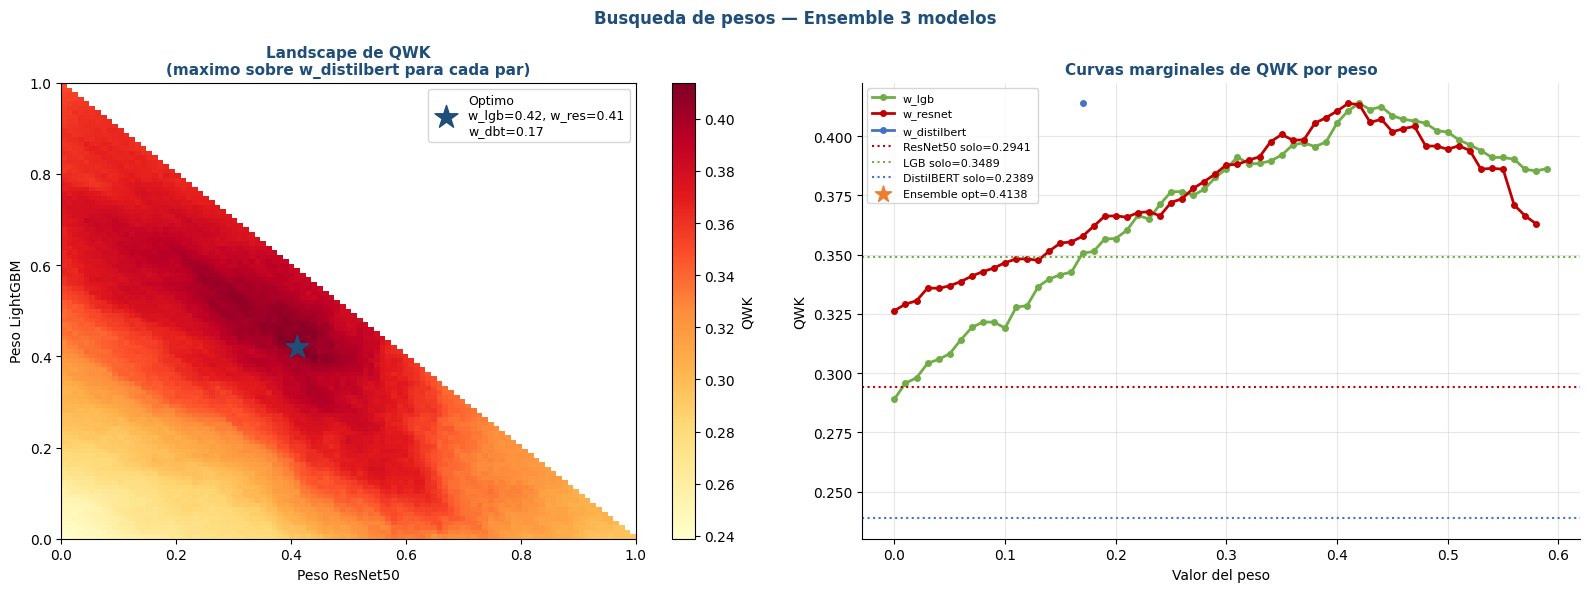

In [11]:
# Pivot: fijar w_distilbert en el valor optimo y mostrar el heatmap LGB vs ResNet
# Esto permite visualizar el landscape de la busqueda 2D
pivot_data = results_df.copy()

# Crear una grilla para el heatmap: para cada (w_lgb, w_resnet) tomar el mejor qwk
heatmap_df = pivot_data.pivot_table(index='w_lgb', columns='w_resnet', values='qwk', aggfunc='max')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
im = axes[0].imshow(heatmap_df.values, origin='lower', aspect='auto',
                    cmap='YlOrRd',
                    extent=[heatmap_df.columns.min(), heatmap_df.columns.max(),
                            heatmap_df.index.min(), heatmap_df.index.max()])
plt.colorbar(im, ax=axes[0], label='QWK')
axes[0].scatter([w_res_opt], [w_lgb_opt], s=300, color=PALETTE['dark'], zorder=5,
                marker='*', label=f'Optimo\nw_lgb={w_lgb_opt}, w_res={w_res_opt}\nw_dbt={w_dbt_opt}')
axes[0].set_xlabel('Peso ResNet50', fontsize=10)
axes[0].set_ylabel('Peso LightGBM', fontsize=10)
axes[0].set_title('Landscape de QWK\n(maximo sobre w_distilbert para cada par)', fontsize=11, fontweight='bold', color=PALETTE['dark'])
axes[0].legend(fontsize=9)

# Curvas marginales: QWK vs peso por modelo (fijando los demas en optimo)
for w_vals, w_name, color, fix in [
    (pesos, 'w_lgb',   PALETTE['lgb'],        {'w_resnet': w_res_opt}),
    (pesos, 'w_resnet',PALETTE['resnet'],      {'w_lgb':    w_lgb_opt}),
    (pesos, 'w_distilbert', PALETTE['distilbert'], {'w_lgb': w_lgb_opt, 'w_resnet': w_res_opt}),
]:
    curve = []
    for w in pesos:
        sub = results_df.copy()
        for k, v in fix.items():
            sub = sub[np.abs(sub[k] - v) < 1e-9]
        row = sub[np.abs(sub[w_name] - round(w,4)) < 1e-9]
        if len(row) > 0:
            curve.append((w, row['qwk'].max()))
    if curve:
        xs, ys = zip(*curve)
        axes[1].plot(xs, ys, 'o-', color=color, linewidth=2, markersize=4, label=w_name)

axes[1].axhline(qwk_resnet,    linestyle=':', color=PALETTE['resnet'],     linewidth=1.5, label=f'ResNet50 solo={qwk_resnet:.4f}')
axes[1].axhline(qwk_lgb,       linestyle=':', color=PALETTE['lgb'],        linewidth=1.5, label=f'LGB solo={qwk_lgb:.4f}')
axes[1].axhline(qwk_distilbert,linestyle=':', color=PALETTE['distilbert'], linewidth=1.5, label=f'DistilBERT solo={qwk_distilbert:.4f}')
axes[1].scatter([], [], s=150, color=PALETTE['ensemble'], marker='*', label=f'Ensemble opt={qwk_opt:.4f}')
axes[1].set_title('Curvas marginales de QWK por peso', fontsize=11, fontweight='bold', color=PALETTE['dark'])
axes[1].set_xlabel('Valor del peso', fontsize=10)
axes[1].set_ylabel('QWK', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Busqueda de pesos — Ensemble 3 modelos', fontsize=12, fontweight='bold', color=PALETTE['dark'])
plt.tight_layout()
plt.show()


## Celda 11 — Gráfico 2: Comparación de QWK


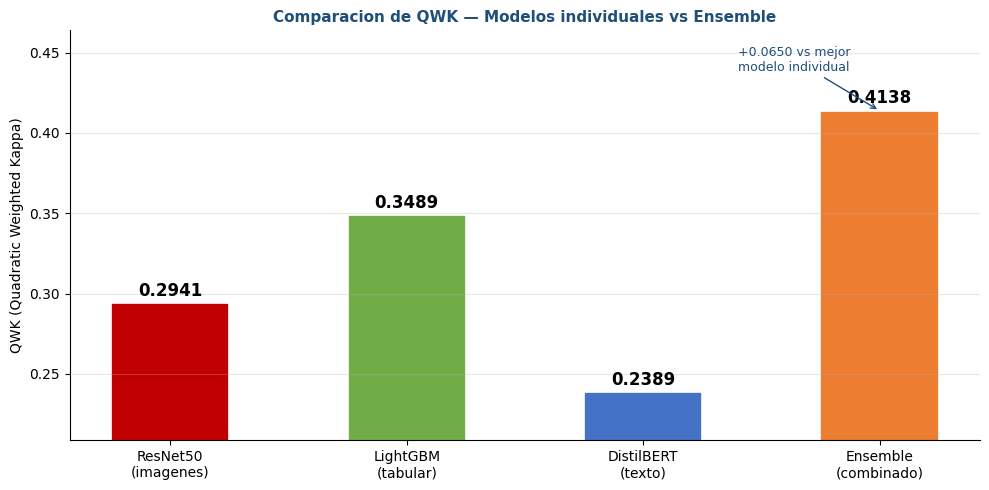

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
modelos = ['ResNet50\n(imagenes)', 'LightGBM\n(tabular)', 'DistilBERT\n(texto)', 'Ensemble\n(combinado)']
valores = [qwk_resnet, qwk_lgb, qwk_distilbert, qwk_opt]
colores = [PALETTE['resnet'], PALETTE['lgb'], PALETTE['distilbert'], PALETTE['ensemble']]
bars = ax.bar(modelos, valores, color=colores, edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(min(valores) - 0.03, max(valores) + 0.05)
ax.set_title('Comparacion de QWK — Modelos individuales vs Ensemble', fontsize=11, fontweight='bold', color=PALETTE['dark'])
ax.set_ylabel('QWK (Quadratic Weighted Kappa)', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
mejora = qwk_opt - max(qwk_resnet, qwk_lgb, qwk_distilbert)
ax.annotate(f'+{mejora:.4f} vs mejor\nmodelo individual',
            xy=(3, qwk_opt), xytext=(2.4, qwk_opt + 0.025),
            arrowprops=dict(arrowstyle='->', color=PALETTE['dark']), fontsize=9, color=PALETTE['dark'])
plt.tight_layout()
plt.show()


## Celda 12 — Gráfico 3: Matrices de confusión


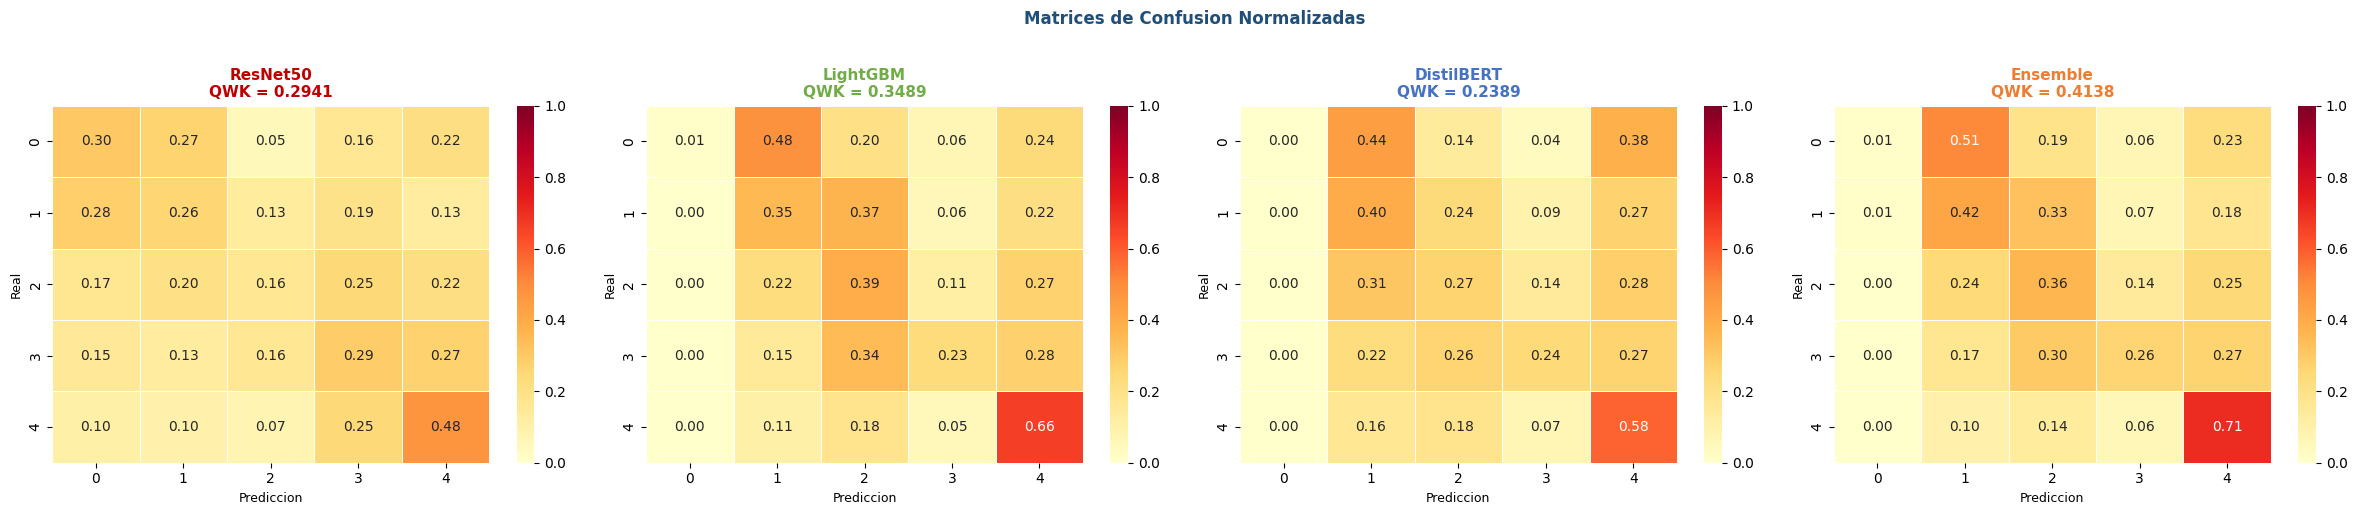

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, (nombre, preds, color) in zip(axes, [
    ('ResNet50',   resnet_preds,    PALETTE['resnet']),
    ('LightGBM',   lgb_preds,       PALETTE['lgb']),
    ('DistilBERT', distilbert_preds, PALETTE['distilbert']),
    ('Ensemble',   ensemble_preds,  PALETTE['ensemble']),
]):
    cm = confusion_matrix(y_true, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.5, linecolor='white',
                xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
    ax.set_title(f'{nombre}\nQWK = {qwk(y_true, preds):.4f}', fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Prediccion', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)
fig.suptitle('Matrices de Confusion Normalizadas', fontsize=12, fontweight='bold', color=PALETTE['dark'], y=1.02)
plt.tight_layout()
plt.show()


## Celda 13 — Gráfico 4: Distribución de predicciones por clase


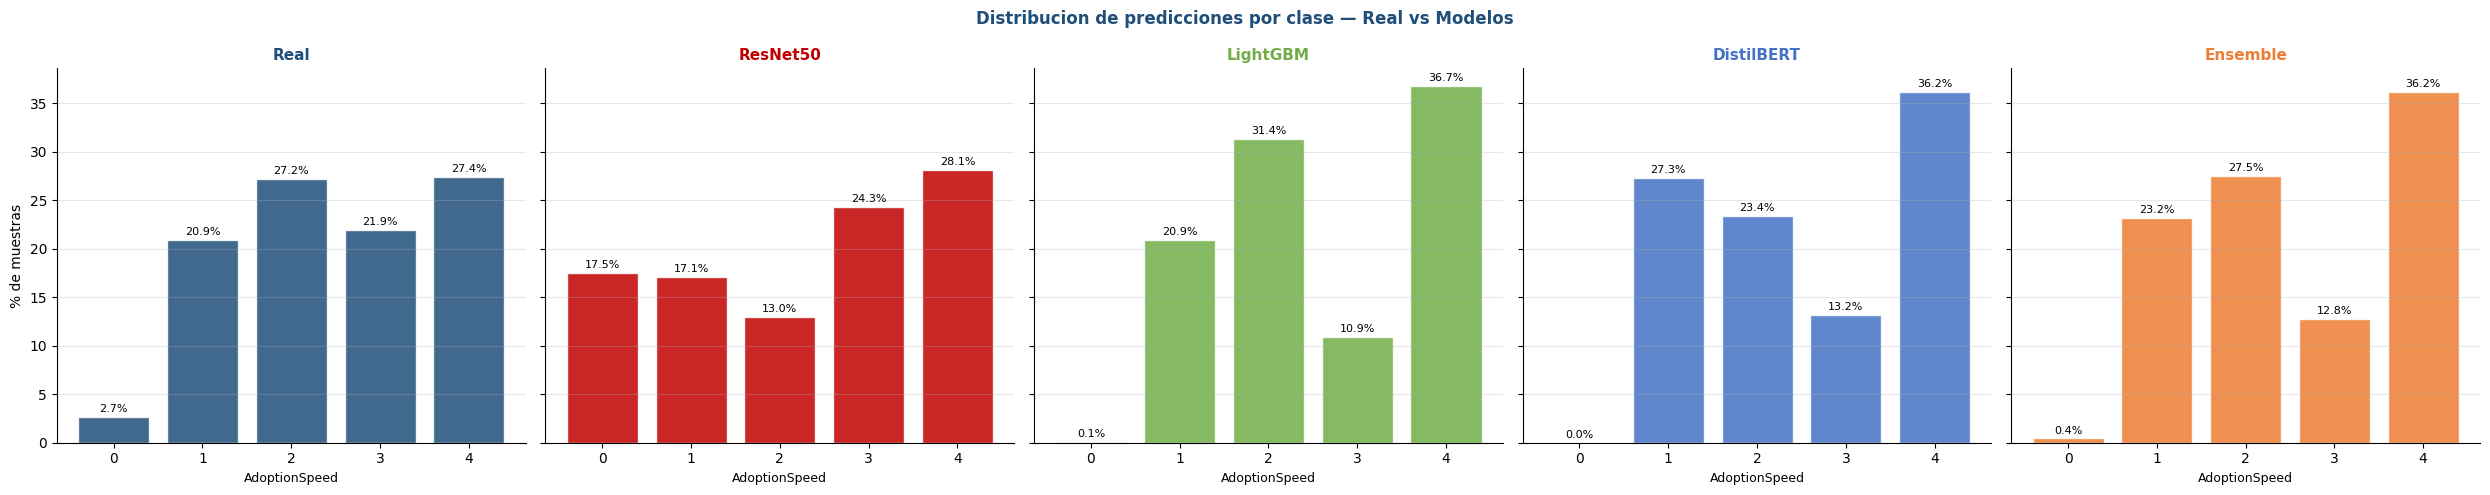

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)
for ax, (nombre, preds, color) in zip(axes, [
    ('Real',      y_true,          PALETTE['dark']),
    ('ResNet50',  resnet_preds,    PALETTE['resnet']),
    ('LightGBM',  lgb_preds,       PALETTE['lgb']),
    ('DistilBERT',distilbert_preds, PALETTE['distilbert']),
    ('Ensemble',  ensemble_preds,  PALETTE['ensemble']),
]):
    counts = [np.sum(np.array(preds) == c) for c in range(5)]
    pcts   = [c / sum(counts) * 100 for c in counts]
    bars = ax.bar(range(5), pcts, color=color, alpha=0.85, edgecolor='white')
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(nombre, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('AdoptionSpeed', fontsize=9)
    ax.set_xticks(range(5))
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[0].set_ylabel('% de muestras', fontsize=10)
fig.suptitle('Distribucion de predicciones por clase — Real vs Modelos', fontsize=12, fontweight='bold', color=PALETTE['dark'])
plt.tight_layout()
plt.show()


## Celda 14 — Gráfico 5: Acuerdo entre modelos


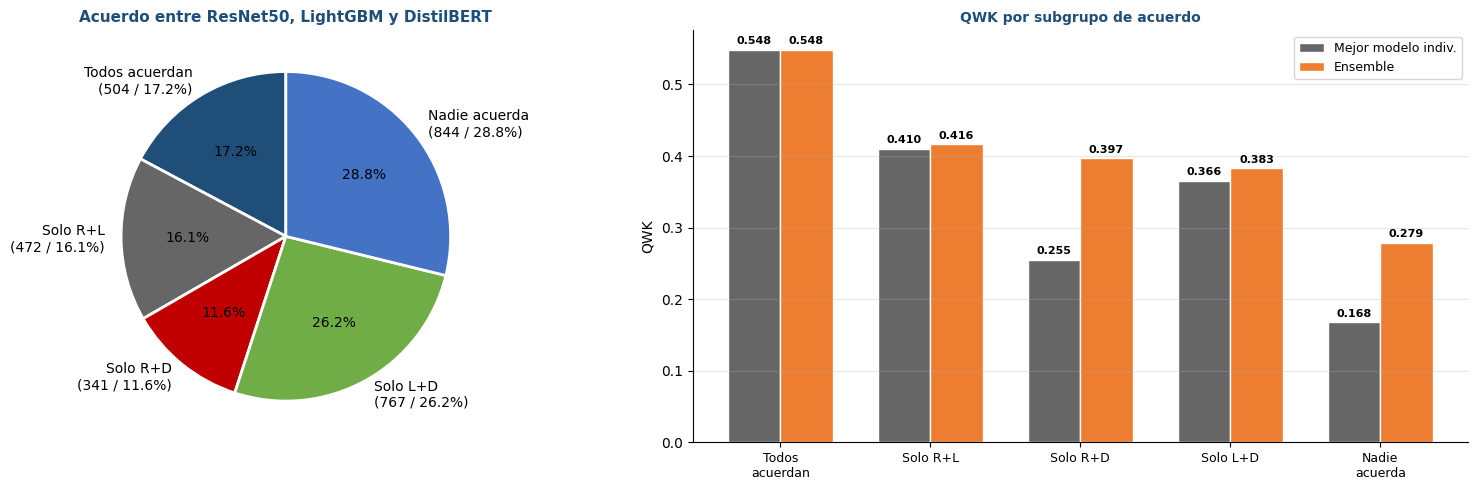

In [15]:
preds_r = np.array(resnet_preds)
preds_l = np.array(lgb_preds)
preds_d = np.array(distilbert_preds)
preds_e = np.array(ensemble_preds)
yt      = np.array(y_true)

# Categorias de acuerdo
todos_acuerdan    = (preds_r == preds_l) & (preds_r == preds_d)
ninguno_acuerda   = (preds_r != preds_l) & (preds_r != preds_d) & (preds_l != preds_d)
solo_rl           = (preds_r == preds_l) & (preds_r != preds_d)
solo_rd           = (preds_r == preds_d) & (preds_r != preds_l)
solo_ld           = (preds_l == preds_d) & (preds_l != preds_r)

def safe_qwk(mask, p): return qwk(yt[mask], p[mask]) if mask.sum() > 1 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pie de acuerdo
sizes  = [todos_acuerdan.sum(), solo_rl.sum(), solo_rd.sum(), solo_ld.sum(), ninguno_acuerda.sum()]
labels = [f'Todos acuerdan\n({todos_acuerdan.sum():,} / {todos_acuerdan.mean()*100:.1f}%)',
          f'Solo R+L\n({solo_rl.sum():,} / {solo_rl.mean()*100:.1f}%)',
          f'Solo R+D\n({solo_rd.sum():,} / {solo_rd.mean()*100:.1f}%)',
          f'Solo L+D\n({solo_ld.sum():,} / {solo_ld.mean()*100:.1f}%)',
          f'Nadie acuerda\n({ninguno_acuerda.sum():,} / {ninguno_acuerda.mean()*100:.1f}%)']
pie_colors = [PALETTE['dark'], PALETTE['gray'], PALETTE['resnet'], PALETTE['lgb'], PALETTE['distilbert']]
axes[0].pie(sizes, labels=labels, colors=pie_colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Acuerdo entre ResNet50, LightGBM y DistilBERT', fontsize=11, fontweight='bold', color=PALETTE['dark'])

# QWK por subgrupo
cats  = ['Todos\nacuerdan', 'Solo R+L', 'Solo R+D', 'Solo L+D', 'Nadie\nacuerda']
masks = [todos_acuerdan, solo_rl, solo_rd, solo_ld, ninguno_acuerda]
vals_e = [safe_qwk(m, preds_e) for m in masks]
vals_best = [max(safe_qwk(m, preds_r), safe_qwk(m, preds_l), safe_qwk(m, preds_d)) for m in masks]
x = np.arange(len(cats))
w = 0.35
bars1 = axes[1].bar(x - w/2, vals_best, w, color=PALETTE['gray'], label='Mejor modelo indiv.', edgecolor='white')
bars2 = axes[1].bar(x + w/2, vals_e,    w, color=PALETTE['ensemble'], label='Ensemble', edgecolor='white')
for bars, vals in [(bars1, vals_best), (bars2, vals_e)]:
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats, fontsize=9)
axes[1].set_title('QWK por subgrupo de acuerdo', fontsize=10, fontweight='bold', color=PALETTE['dark'])
axes[1].set_ylabel('QWK', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Celda 15 — Gráfico 6: Confianza promedio por clase


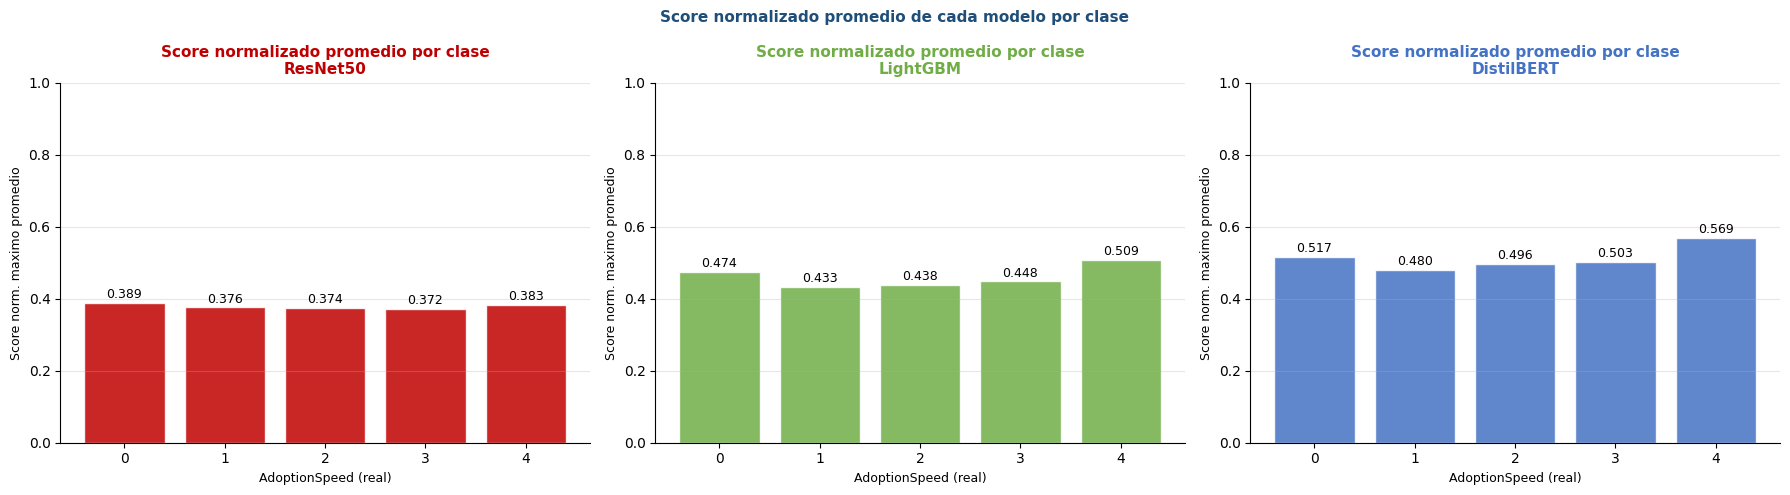

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, nombre, color) in zip(axes, [
    ('resnet_norm',     'ResNet50',   PALETTE['resnet']),
    ('lgb_norm',        'LightGBM',   PALETTE['lgb']),
    ('distilbert_norm', 'DistilBERT', PALETTE['distilbert']),
]):
    conf_por_clase = []
    for c in range(5):
        mask = y_true == c
        conf = np.vstack(merged[col][mask].values).max(axis=1).mean() if mask.sum() > 0 else 0
        conf_por_clase.append(conf)
    bars = ax.bar(range(5), conf_por_clase, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, conf_por_clase):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Score normalizado promedio por clase\n{nombre}', fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('AdoptionSpeed (real)', fontsize=9)
    ax.set_ylabel('Score norm. maximo promedio', fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(5))
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle('Score normalizado promedio de cada modelo por clase', fontsize=11, fontweight='bold', color=PALETTE['dark'])
plt.tight_layout()
plt.show()


## Celda 16 — Guardar resultados

Guarda los archivos en `/content/`. Para descargarlos: panel izquierdo → ícono de carpeta → clic derecho sobre el archivo → **Download**.


In [17]:
merged['ensemble_norm'] = blend_opt
merged['ensemble_pred'] = ensemble_preds
output = merged[['PetID', 'AdoptionSpeed', 'ensemble_pred', 'ensemble_norm']].copy()

dump(output, '/content/ensemble_predictions.joblib')
df_met.to_csv('/content/ensemble_metricas.csv')
results_df.to_csv('/content/ensemble_pesos.csv', index=False)

import json
pesos_opt = {
    'w_lgb':        w_lgb_opt,
    'w_resnet':     w_res_opt,
    'w_distilbert': w_dbt_opt,
    'qwk_ensemble': qwk_opt,
    'qwk_lgb':      qwk_lgb,
    'qwk_resnet':   qwk_resnet,
    'qwk_distilbert': qwk_distilbert,
}
with open('/content/ensemble_pesos_optimos.json', 'w') as f:
    json.dump(pesos_opt, f, indent=2)

print('Archivos guardados:')
print('  /content/ensemble_predictions.joblib')
print('  /content/ensemble_metricas.csv')
print('  /content/ensemble_pesos.csv')
print('  /content/ensemble_pesos_optimos.json')
print(f'\nPesos optimos: LGB={w_lgb_opt:.2f} | ResNet={w_res_opt:.2f} | DistilBERT={w_dbt_opt:.2f}')
print('\nPara descargar: panel izquierdo -> carpeta -> clic derecho -> Download')


Archivos guardados:
  /content/ensemble_predictions.joblib
  /content/ensemble_metricas.csv
  /content/ensemble_pesos.csv
  /content/ensemble_pesos_optimos.json

Pesos optimos: LGB=0.42 | ResNet=0.41 | DistilBERT=0.17

Para descargar: panel izquierdo -> carpeta -> clic derecho -> Download
